In [1]:
import pandas as pd    
import json
import matplotlib.pyplot as plt


MODEL_LIST = [
    "Qwen_Qwen2.5-3B-Instruct-GPTQ-Int8",
    "Qwen_Qwen2.5-1.5B-Instruct",
    "RedHatAI_gemma-2-2b-it-quantized.w4a16",
    "RedHatAI_SmolLM-1.7B-Instruct-quantized.w8a16"
]

MODEL_NAME=MODEL_LIST[2]
REQUEST_RATE="-request_rate10.0"
PATH="./data/artifacts/" + MODEL_NAME + "-openai-chat" + REQUEST_RATE + "/"
PREFIX="Exclusive"


# Exploratory

## Metrics:
### Recorded:
* request_latency:
* time_to_first_token
* inter_token_latency
* output_token_count
* input_sequence_length

Note: Metrics are collected per request individually.

### Derived:
* request_throughput
* output_token_throughput

### Def:
* Time to First Token (TTFT)
```
                                                                            TTFT = request.response[0].perf_ns - request.start_perf_ns
                                                            response[0].perf_ns = network_latency + queuing_delay + prompt_processing + first_token_generation
```
* Time to Second Token (TTST)
```
                                                                            TTST = request.responses[1].perf_ns - request.responses[0].perf_ns
                                                            // captures startup generation overhead, separate from steady state streaming throughput
                                                            // Requires at least 2 non-empty response chunks to compute the time between first and second tokens.
```
* Time to First Output Token (TTFO)
```
                                                                            TTFO = TTFT Given non-reasoning model
                                                            // In this research, we only focus on non-reasoning models, otherwise TTFO != TTFT
```
* Inter Token Latency (ITL)
```
                                                                            ITL = (request_latency_ns - time_to_first_token_ns) / (output_sequence_length - 1)
                                                            // steady-state token generation rate. Requires an output sequence length of at least 2 tokens.
```
* Inter Chunk Latency (ICL)
```
                                                                            ITL = (request_latency_ns - time_to_first_token_ns) / (output_sequence_length - 1)
                                                            // steady-state token generation rate. Requires an output sequence length of at least 2 tokens.
```
* Inter Chunk Latency (ICL)
```
                                                                            ICL = [request.responses[i].perf_ns - request.responses[i-1].perf_ns for i in range(1, len(request.responses))]
                                                            // Requires an output sequence length of at least 2 tokens.
                                                            // Useful for detecting variability, jitter, or issues in streaming delivery.
```
* Prefill Throughput Per User
```
                                                                            prefill_throughput_per_user = input_sequence_length / time_to_first_token_seconds
                                                            // Useful for understanding input processing capacity and bottlenecks.
```
* Output Token Count
```
                                                                            output_token_count = len(tokenizer.encode(content, add_special_tokens=False))
```
* Output Sequence Length (OSL)
```
                                                            // For models that do not support/separate reasoning tokens, OSL equals the output token count.
```
* Input Sequence Length (ISL)
```
                                                                            input_sequence_length = len(tokenizer.encode(prompt, add_special_tokens=False))
```
* Total Output Tokens
```
                                                                            total_output_tokens = sum(r.output_token_count for r in records if r.valid)
                                                            // Useful for capacity planning and cost estimation.
```
* Total Input Sequence Length
```
                                                                            total_isl = sum(r.input_sequence_length for r in records if r.valid)
                                                            // Useful for understanding the input workload, capacity planning, and analyzing the relationship between input size and system performance.
```
* Request Latency
```
                                                                            request_latency_ns = request.responses[-1].perf_ns - request.start_perf_ns
                                                            // Includes all components: network time, queuing, prompt processing, token generation, and response transmission.
```


In [43]:
data = pd.read_json(PATH + PREFIX + "_raw.jsonl", lines=True)

In [7]:
data.keys()

Index(['metadata', 'start_perf_ns', 'request_headers', 'status', 'responses',
       'payload'],
      dtype='object')

In [15]:
assert len(data["metadata"]) == len(data["start_perf_ns"]) == len(data["request_headers"]) == len(data["status"]) == len(data["responses"]) == len(data["payload"])

In [8]:
data["metadata"][0]

{'session_num': 24,
 'x_request_id': '0af11cbd-8fd1-4b43-87c2-3b7475afff11',
 'x_correlation_id': '303fbbce-deda-4d31-86e0-85e42ccde66f',
 'conversation_id': '406c738a-4a37-4a16-bada-0a97f6083465',
 'turn_index': 0,
 'credit_issued_ns': 1788879798927932813,
 'request_start_ns': 1788879798930056901,
 'request_ack_ns': 1788879799152929033,
 'request_end_ns': 1788879814987318118,
 'worker_id': 'worker_d0e7953b',
 'record_processor_id': 'record_processor_759a465a',
 'benchmark_phase': 'profiling',
 'phase_index': 0,
 'profiling_index': 0,
 'phase_name': 'profiling',
 'phase_kind': 'profiling',
 'was_cancelled': False,
 'context_overflow_skip': False,
 'agent_depth': 0,
 'root_correlation_id': '303fbbce-deda-4d31-86e0-85e42ccde66f'}

In [16]:
data["start_perf_ns"][0]

np.int64(12608430320583921)

In [17]:
data["request_headers"][0]

{'User-Agent': 'aiperf/0.12.0',
 'X-Request-ID': '0af11cbd-8fd1-4b43-87c2-3b7475afff11',
 'X-Correlation-ID': '303fbbce-deda-4d31-86e0-85e42ccde66f',
 'Accept': 'text/event-stream',
 'Content-Type': 'application/json'}

In [18]:
data["status"][0]

np.int64(200)

In [51]:
data["responses"][0]

[{'perf_ns': 12608434512372745,
  'packets': [{'name': 'data',
    'value': '{"id":"chatcmpl-0af11cbd-8fd1-4b43-87c2-3b7475afff11","object":"chat.completion.chunk","created":1788879798,"model":"Qwen/Qwen2.5-3B-Instruct-GPTQ-Int8","choices":[{"index":0,"delta":{"role":"assistant","content":""},"logprobs":null,"finish_reason":null}],"prompt_token_ids":null,"prompt_text":null}'}]},
 {'perf_ns': 12608434512372745,
  'packets': [{'name': 'data',
    'value': '{"id":"chatcmpl-0af11cbd-8fd1-4b43-87c2-3b7475afff11","object":"chat.completion.chunk","created":1788879798,"model":"Qwen/Qwen2.5-3B-Instruct-GPTQ-Int8","choices":[{"index":0,"delta":{"content":"It"},"logprobs":null,"finish_reason":null,"token_ids":null}]}'}]},
 {'perf_ns': 12608435341038001,
  'packets': [{'name': 'data',
    'value': '{"id":"chatcmpl-0af11cbd-8fd1-4b43-87c2-3b7475afff11","object":"chat.completion.chunk","created":1788879798,"model":"Qwen/Qwen2.5-3B-Instruct-GPTQ-Int8","choices":[{"index":0,"delta":{"content":" seems"

In [20]:
data["payload"][0]

{'messages': [{'role': 'user',
   'content': 'DERER We have lost best half of our affair FIRST MURDERER Well lets away and say how much is done Exeunt SCENE IV The same A Room of state in the Palace A banquet prepared Enter Macbeth Lady Macbeth Ross Lennox Lords and Attendants MACBETH You know your own degrees sit down At first And last the hearty welcome LORDS Thanks to your Majesty MACBETH Ourself will mingle with society And play the humble host Our hostess keeps her state but in best time We will require her welcome LADY MACBETH Pronounce it for me sir to all our friends For my heart speaks they are welcome Enter first Murderer to the door MACBETH See they encounter thee with their hearts thanks Both sides are even here Ill sit i th midst Be large in mirth anon well drink a measure The table round Theres blood upon thy face MURDERER Tis Banquos then MACBETH Tis better thee without than he within Is he dispatchd MURDERER My lord his throat is cut That I did for him MACBETH Thou art 

In [49]:
response = ""
for packets in data["responses"][0]:
    for packet in packets["packets"]:
        if packet["value"].startswith("{"):
            for choice in json.loads(packet["value"])["choices"]:
                response += choice["delta"]["content"]

print(response)

It seems like you've provided an excerpt from Act V, Scene 4 of Shakespeare's tragedy "Macbeth". This scene continues the story where Macbeth has just killed King Duncan and Banquo, and now Lady Macbeth is welcoming guests to the banquet. The scene also introduces the ghost of Banquo, which adds to the supernatural and unsettling atmosphere.

The excerpt describes Macbeth's initial reaction to the murder of Banquo, his concern about Fleance (Banquo's son), and his reflection on the consequences of his actions. Lady Macbeth tries to reassure him and welcomes the guests to the banquet, which is filled with tension and dread.

Given this context, let me know if you need any specific information or analysis related to this passage, or if you'd like to continue the conversation in another part of the play. I'm here to help provide insights and explanations based on Shakespeare's text.


# Analysis

In [ ]:
def generate_dataframe(data):
    df = pd.DataFrame()
    for i in range(len(data["responses"])):
        assert data["request_headers"][i]["X-Request-ID"] == data["metadata"][i]["x_request_id"]
        assert len(data["payload"][i]["messages"]) == 1
        row = data["metadata"][i]
        row["start_perf_ns"] = data["start_perf_ns"][i]
        row["status"] = data["status"][i]
        row["role"] = data["payload"][i]["messages"][0]["role"]
        row["content"] = data["payload"][i]["messages"][0]["content"]
        row["model"] = data["payload"][i]["model"]
        row["response"] = ""
        for packets in data["responses"][i]:
            for packet in packets["packets"]:
                if packet["value"].startswith("{"):
                    jsonObj = json.loads(packet["value"])
                    assert row["model"] == jsonObj["model"]
                    for choice in jsonObj["choices"]:
                        row["response"] += choice["delta"]["content"]

        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    return df


def plot_pcie_util(model_name: str, prefix: str):
    REQUEST_RATE = "-openai-chat-request_rate10.0"
    PATH = "./data/artifacts/" + model_name + REQUEST_RATE + "/"
    df = pd.read_csv(PATH + "Exclusive_raw_gpu.csv")

    X_raw = df.loc[df["metric"] == "DCGM_FI_PROF_PCIE_RX_BYTES", "timestamp"]
    X = pd.to_datetime(X_raw).to_numpy()  # keep as datetime64 for plotting

    X_int = pd.to_datetime(X_raw).astype("int64") // 10**9  # seconds, for the math
    duration_sec = X_int.max() - X_int.min()

    mean = (df.loc[df["metric"] == "DCGM_FI_PROF_PCIE_RX_BYTES", "value"].mean() / 1024 / 1024 / 1024)
    std = (df.loc[df["metric"] == "DCGM_FI_PROF_PCIE_RX_BYTES", "value"].std() / 1024 / 1024 / 1024)

    Y = df.loc[df["metric"] == "DCGM_FI_PROF_PCIE_RX_BYTES", "value"].to_numpy()
    
    # Plot
    fig, ax = plt.subplots()
    ax.plot(X, Y, marker="o", label=f"{model_name}", alpha=0.7)



    # ax.xaxis.set_major_formatter(md.DateFormatter("%Y-%m-%d %H:%M:%S"))
    fig.autofmt_xdate()

    plt.xlabel("Time")
    plt.ylabel("PCIe RX")
    plt.title(f"PCIe Utilization [Mean: {mean:.2f} GB/s ± {std:.2f} GB/s]")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return X_int, Y

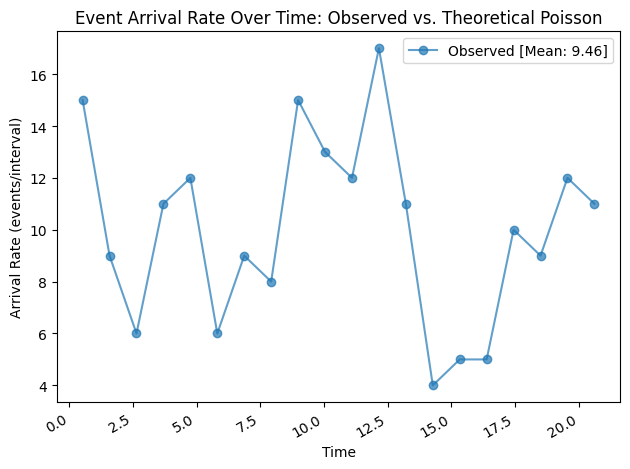

In [53]:
import datetime as dt
import matplotlib.dates as md
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import factorial



df["shifted_credit_issued_ns"] = df["credit_issued_ns"] - df["credit_issued_ns"].min()
timestamps = df["shifted_credit_issued_ns"].values / 1e9

counts, bin_edges = np.histogram(timestamps, bins=20)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# --- Theoretical Poisson arrival rate ---
mean = df.shape[0] / (df["credit_issued_ns"].max() - df["credit_issued_ns"].min())
mean = mean * 1e9



# Plot
fig, ax = plt.subplots()
ax.plot(bin_centers, counts, marker="o", label=f"Observed [Mean: {mean:.2f}]", alpha=0.7)



# ax.xaxis.set_major_formatter(md.DateFormatter("%Y-%m-%d %H:%M:%S"))
fig.autofmt_xdate()

plt.xlabel("Time")
plt.ylabel("Arrival Rate (events/interval)")
plt.title("Event Arrival Rate Over Time: Observed vs. Theoretical Poisson")
plt.legend()
plt.tight_layout()
plt.show()

In [82]:
df.iloc[0]

session_num                                                             14
x_request_id                          c6423107-1444-45c6-9226-d3e32bb69590
x_correlation_id                      61de5c09-9f1d-47ba-81b6-c0854e99a14b
conversation_id                       fa3b7e38-97bf-47d8-9043-8dde3ee20b31
turn_index                                                               0
credit_issued_ns                                       1788974808056283836
request_start_ns                                       1788974808058654252
request_ack_ns                                         1788974808336277270
request_end_ns                                         1788974811432722647
worker_id                                                  worker_be39a3ea
record_processor_id                              record_processor_cd17867f
benchmark_phase                                                  profiling
phase_index                                                              0
profiling_index          

In [3]:
PATH + PREFIX + "_raw.jsonl"

'./data/artifacts/Qwen_Qwen2.5-3B-Instruct-GPTQ-Int8-request_rate10.0/Concurrent_raw.jsonl'

In [10]:
import subprocess
import datetime as dt

for MODEL_NAME in MODEL_LIST:
    print(f"Extracting raw telemetry for model: {MODEL_NAME}")
    REQUEST_RATE = "-openai-chat-request_rate10.0"
    PATH = "./data/artifacts/" + MODEL_NAME + REQUEST_RATE + "/"
    PREFIX = "Exclusive"
    data = pd.read_json(PATH + PREFIX + "_raw.jsonl", lines=True)
    df = generate_dataframe(data)

    start_time = dt.datetime.fromtimestamp(
        df["request_start_ns"].min() / 1e9, tz=dt.timezone.utc
    ).strftime("%Y-%m-%dT%H:%M:%SZ")
    end_time = dt.datetime.fromtimestamp(
        df["request_end_ns"].max() / 1e9, tz=dt.timezone.utc
    ).strftime("%Y-%m-%dT%H:%M:%SZ")

    print(f"Start Time: {start_time}, End Time: {end_time}")
    subprocess.run([
        "./utils/scrapper",
        "-addr", "http://localhost:9090",
        "-start", start_time,
        "-end", end_time,
        "-step", "5s",
        "-csv-file", PATH + PREFIX + "_raw_gpu.csv",
    ])

Extracting raw telemetry for model: Qwen_Qwen2.5-3B-Instruct-GPTQ-Int8
Start Time: 2026-09-16T23:37:29Z, End Time: 2026-09-16T23:39:54Z
Prometheus : http://localhost:9090
Start      : 2026-09-16T23:37:29Z
End        : 2026-09-16T23:39:54Z
Step       : 5s
Metrics    : 10 DCGM metrics


=== DCGM_FI_PROF_GR_ENGINE_ACTIVE ===
    Ratio of time the graphics engine is active

    Labels: map[UUID:GPU-9c52b386-46a3-ee9a-0bb6-b856f08f500c __name__:DCGM_FI_PROF_GR_ENGINE_ACTIVE container:nvidia-dcgm-exporter device:nvidia0 endpoint:gpu-metrics gpu:0 hostname:baysan instance:10.100.0.45:9400 job:nvidia-dcgm-exporter modelName:NVIDIA A30 namespace:gpu-operator pci_bus_id:00000000:05:00.0 pod:nvidia-dcgm-exporter-g665p service:nvidia-dcgm-exporter]
    Timestamp                 Value
    ---------                 -----
    2026-09-16T23:37:29Z    0.000000
    2026-09-16T23:37:34Z    0.035206
    2026-09-16T23:37:39Z    0.249975
    2026-09-16T23:37:44Z    0.249974
    2026-09-16T23:37:49Z    0.249

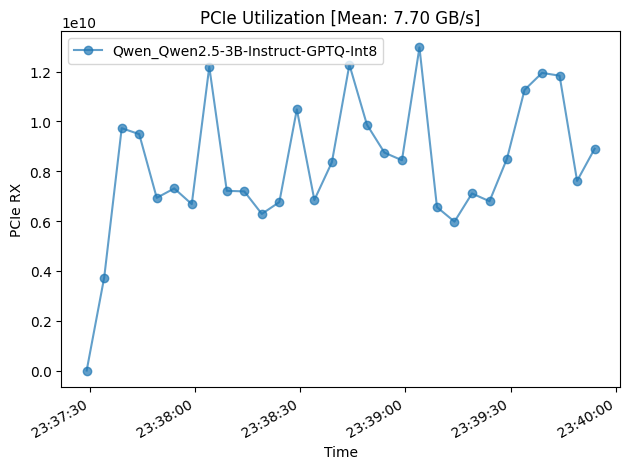

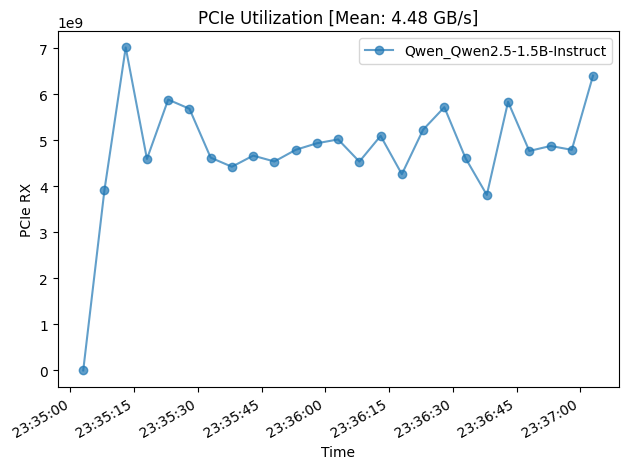

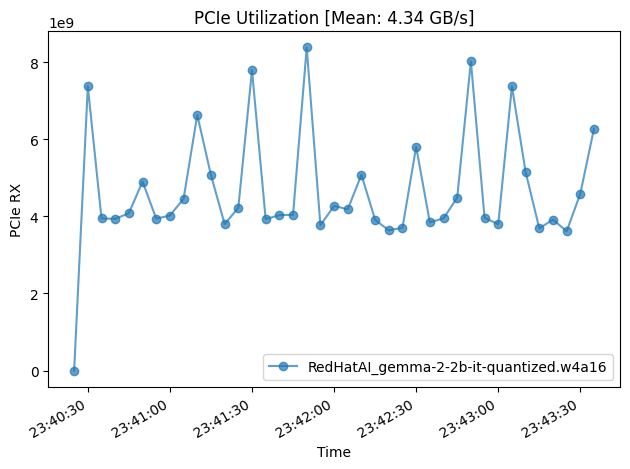

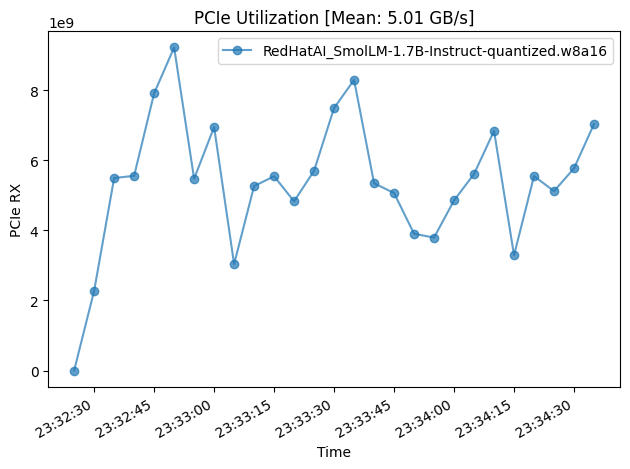

In [11]:
for MODEL_NAME in MODEL_LIST:
        plot_pcie_util(MODEL_NAME, "Exclusive")


# Linear Modeling of Throughput

In [3]:
from sim.vllm_server import vlllm_server


vllm_server_dict = {}

for MODEL_NAME in MODEL_LIST:
    REQUEST_RATE="-request_rate10.0"
    PATH="./data/artifacts_2/" + MODEL_NAME + "-openai-chat" + REQUEST_RATE + "/"
    vllm_server_dict[MODEL_NAME] = vlllm_server(MODEL_NAME, PATH)
    vllm_server_dict[MODEL_NAME].analyze()


        

Qwen_Qwen2.5-3B-Instruct-GPTQ-Int8:
		PCIe Demand: 7.37 GB/s
		Base Throughput: 468.84 tokens/s
		Concurrent Throughput: 292.32 tokens/s
Qwen_Qwen2.5-1.5B-Instruct:
		PCIe Demand: 7.70 GB/s
		Base Throughput: 616.21 tokens/s
		Concurrent Throughput: 280.14 tokens/s
RedHatAI_gemma-2-2b-it-quantized.w4a16:
		PCIe Demand: 4.22 GB/s
		Base Throughput: 471.62 tokens/s
		Concurrent Throughput: 351.13 tokens/s
RedHatAI_SmolLM-1.7B-Instruct-quantized.w8a16:
		PCIe Demand: 4.30 GB/s
		Base Throughput: 275.57 tokens/s
		Concurrent Throughput: 212.49 tokens/s
